In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

0.007539999999999999
mortality increase due to covid: 6.071235286747902


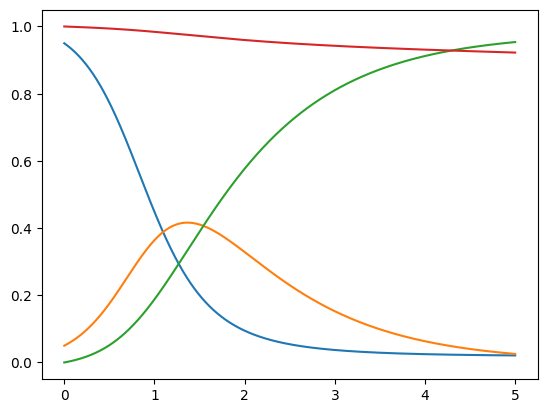

0.9223392932609975
Loss of:  0.0379645220714981
deaths 0.0776607067390025


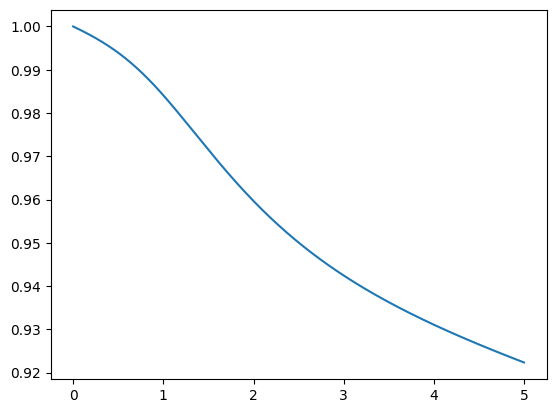

In [28]:
mu = np.mean([7.4, 7.4, 7.6, 7.7, 7.6])/1000 #average 2015-2019 mortality rate (statscan)
print(mu)


DB = 1
P = mu*DB
# mu * (1 + mort_factor) = case fatality rate + general mortality
IFR = 0.15 / 100 # estimated 0.15% 
IFRPerYear = 1 - (1-IFR)**(36.5) #cases last ~10 days on average, do a little math to get yearly survival equiv
mort_factor = IFRPerYear/mu -1 
print("mortality increase due to covid:",mort_factor)
mort_factor = 6
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 4 #estimate of R0 in Canada at initial outbreak
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

plt.plot(t, y0[:,0:4])
plt.show()
print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
#print(EPV_ben)
#print(EPV_prem)
print("Loss of: ", EPV_ben - EPV_prem)
print("deaths", 1- y0[-1,3])
plt.plot(t,y0[:,3])
plt.show()